1. Постройте SARIMA-модель ряда, подобрав параметры с лучшей метрикой AIC, и выведите ее график.
2. Получите по фичам прогноз на следующие 7 дней с использованием какой-нибудь модели из sklearn или бустинга.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('time_series_hw.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
series = df['value']

In [2]:
# Проверка стационарности
def check_stationarity(timeseries):
    result = adfuller(timeseries.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    return result[1] < 0.05

print("Стационарность исходного ряда:")
is_stationary = check_stationarity(series)

Стационарность исходного ряда:
ADF Statistic: -1.7181
p-value: 0.4218


In [3]:
# Подбор параметров SARIMA
from itertools import product

p = d = q = range(0, 2)
P = D = Q = range(0, 2)
s = 12

best_aic = float('inf')
best_params = None

param_combinations = list(product(p, d, q, P, D, Q))

for param in param_combinations:
    try:
        model = SARIMAX(series,
                       order=(param[0], param[1], param[2]),
                       seasonal_order=(param[3], param[4], param[5], s))
        fitted_model = model.fit(disp=False)

        if fitted_model.aic < best_aic:
            best_aic = fitted_model.aic
            best_params = param
    except:
        continue

print(f"Лучшие параметры: SARIMA{best_params[:3]}x{best_params[3:6]}{s}")
print(f"Лучший AIC: {best_aic:.2f}")

Лучшие параметры: SARIMA(1, 1, 1)x(0, 1, 1)12
Лучший AIC: 2617.43


In [4]:
# Построение SARIMA модели
final_model = SARIMAX(series,
                     order=best_params[:3],
                     seasonal_order=(best_params[3], best_params[4], best_params[5], s))
fitted_final = final_model.fit()

print(fitted_final.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  397
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1304.713
Date:                            Wed, 19 Nov 2025   AIC                           2617.426
Time:                                    13:15:35   BIC                           2633.229
Sample:                                01-01-1985   HQIC                          2623.694
                                     - 01-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1514      0.049      3.119      0.002       0.056       0.247
ma.L1         -0.9494      0.034   

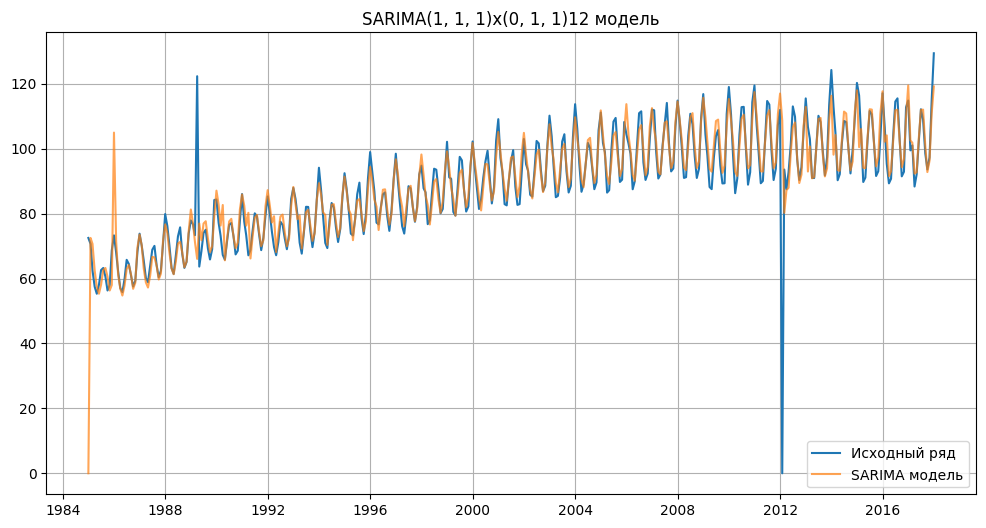

In [5]:
# График SARIMA модели
fitted_values = fitted_final.fittedvalues
plt.figure(figsize=(12, 6))
plt.plot(series, label='Исходный ряд')
plt.plot(fitted_values, label='SARIMA модель', alpha=0.7)
plt.title(f'SARIMA{best_params[:3]}x{best_params[3:6]}{s} модель')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Прогноз на 7 дней (Задание 2)
from sklearn.ensemble import RandomForestRegressor

# Фичи
def create_features(df, lags=7):
    df = df.copy()
    # Лаги
    for i in range(1, 8):
        df[f'lag_{i}'] = df['value'].shift(i)
    # Скользящие статистики
    df['rolling_mean_7'] = df['value'].rolling(window=7).mean()
    df['rolling_std_7'] = df['value'].rolling(window=7).std()
    return df

df_features = create_features(df)
df_features = df_features.dropna()

X = df_features.drop('value', axis=1)
y = df_features['value']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

last_features = X.iloc[-1:].copy()
future_predictions = []

for i in range(7):
    next_pred = model.predict(last_features)[0]
    future_predictions.append(next_pred)

    new_features = last_features.copy()
    for j in range(1, 8):
        if j == 1:
            new_features[f'lag_{j}'] = next_pred
        else:
            new_features[f'lag_{j}'] = last_features[f'lag_{j-1}'].values[0]

    last_features = new_features

print("Прогноз на 7 дней:")
print(future_predictions)

Прогноз на 7 дней:
[np.float64(123.23122000000004), np.float64(116.93576400000008), np.float64(103.24735700000002), np.float64(91.57226899999998), np.float64(97.27236700000003), np.float64(116.55390200000002), np.float64(120.80967999999999)]
